# Retail Sales Performance Analysis & Profitability Insights Report
### Business-Oriented Exploratory Data Analysis
Author: Chathura Morakanda
Tools: Python | Pandas | Visualization  

# Executive Summary

This project presents a structured end-to-end analysis of a retail sales dataset to evaluate revenue trends, profitability drivers, and operational risks.

Key Findings:

• Revenue shows steady year-over-year growth  
• Technology is the most profitable category  
• High discount levels significantly reduce profit margins  
• A small group of sub-categories drives a large portion of revenue  
• A measurable number of transactions generate negative profit  

Strategic Recommendations:

• Optimize discount policies to protect margins  
• Prioritize high-profit categories and sub-categories  
• Reduce loss-making transactions  
• Implement region-specific growth strategies  

This notebook demonstrates a complete workflow from raw data cleaning to business insight generation.

## 1. Business Objective

The purpose of this analysis is to:

- Assess overall sales performance
- Identify profitability drivers
- Evaluate the impact of discounting
- Analyze category and regional contribution
- Generate actionable strategic insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv('/kaggle/input/datasets/bravehart101/sample-supermarket-dataset/SampleSuperstore.csv')
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [3]:
df.tail()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
9989,Second Class,Consumer,United States,Miami,Florida,33180,South,Furniture,Furnishings,25.248,3,0.2,4.1028
9990,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Furniture,Furnishings,91.960,2,0.0,15.6332
9991,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Technology,Phones,258.576,2,0.2,19.3932
9992,Standard Class,Consumer,United States,Costa Mesa,California,92627,West,Office Supplies,Paper,29.600,4,0.0,13.3200
9993,Second Class,Consumer,United States,Westminster,California,92683,West,Office Supplies,Appliances,243.160,2,0.0,72.9480


## 2. Data Understanding

In [4]:
df.shape

(9994, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [6]:
df.describe()

,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [7]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

## 3. Data Cleaning

In [8]:
df.duplicated().sum()

np.int64(17)

###Remove Duplicates

In [9]:
df.drop_duplicates(inplace=True)

Validate Negative Profit Transactions

In [10]:
df[df['Profit'] < 0].head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
14,Standard Class,Home Office,United States,Fort Worth,Texas,76106,Central,Office Supplies,Appliances,68.8100,5,0.80,-123.8580
15,Standard Class,Home Office,United States,Fort Worth,Texas,76106,Central,Office Supplies,Binders,2.5440,3,0.80,-3.8160
23,Second Class,Consumer,United States,Philadelphia,Pennsylvania,19140,East,Furniture,Chairs,71.3720,2,0.30,-1.0196
27,Standard Class,Consumer,United States,Philadelphia,Pennsylvania,19140,East,Furniture,Bookcases,3083.4300,7,0.50,-1665.0522


Cleaning Summary

In [11]:
cleaning_summary = pd.DataFrame({
    "Step": [
        "Removed duplicates",
        "Checked missing values",
        "Validated negative profits"
    ],
    "Status": [
        "Completed",
        "No significant missing values",
        "Reviewed"
    ]
})

cleaning_summary

,Step,Status
0,Removed duplicates,Completed
1,Checked missing values,No significant missing values
2,Validated negative profits,Reviewed


## 4. Exploratory Data Analysis

###📊 6.1 Sales Trend Over Time

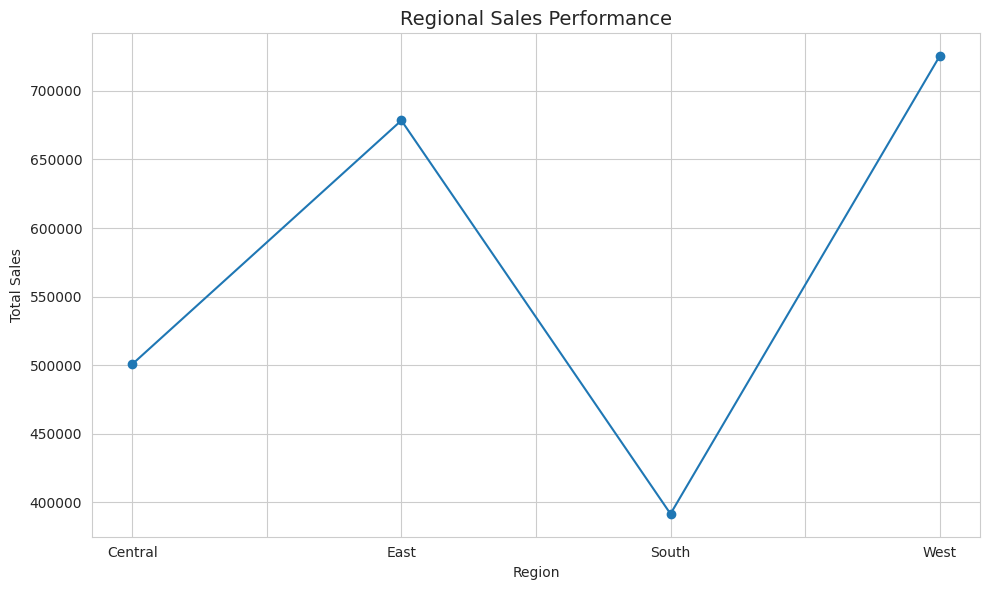

In [12]:
sales_trend = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(10,6))
sales_trend.plot(marker='o')
plt.title("Regional Sales Performance", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

### Insight

Sales demonstrate consistent growth East and West regions, indicating positive revenue momentum and market penetration.

📊 6.2 Sales by Category

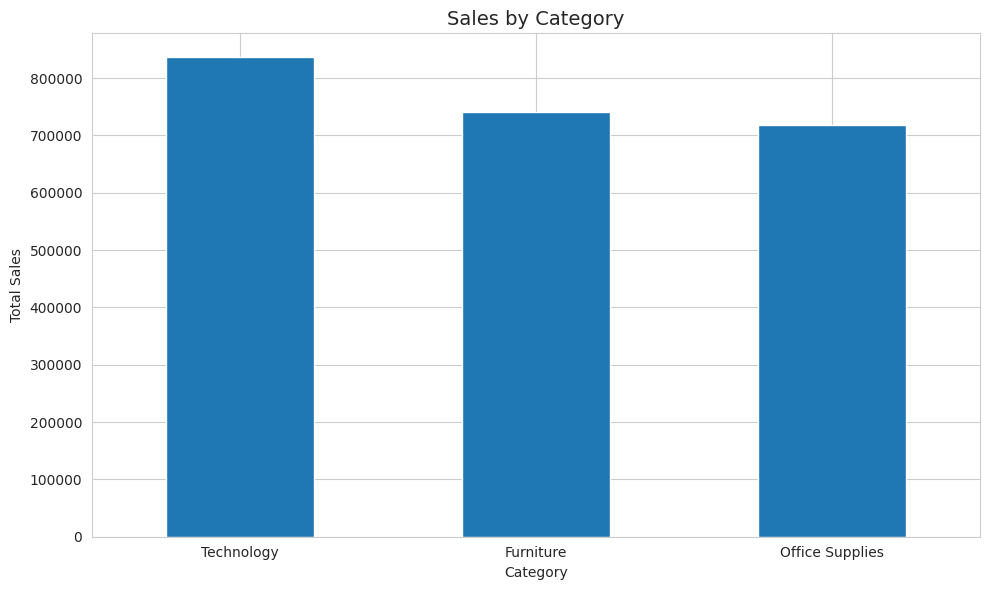

In [13]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
category_sales.plot(kind='bar')
plt.title("Sales by Category", fontsize=14)
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Insight

Technology and Furniture dominate revenue contribution, with Technology generating stronger profitability.

📊 6.3 Profit by Category

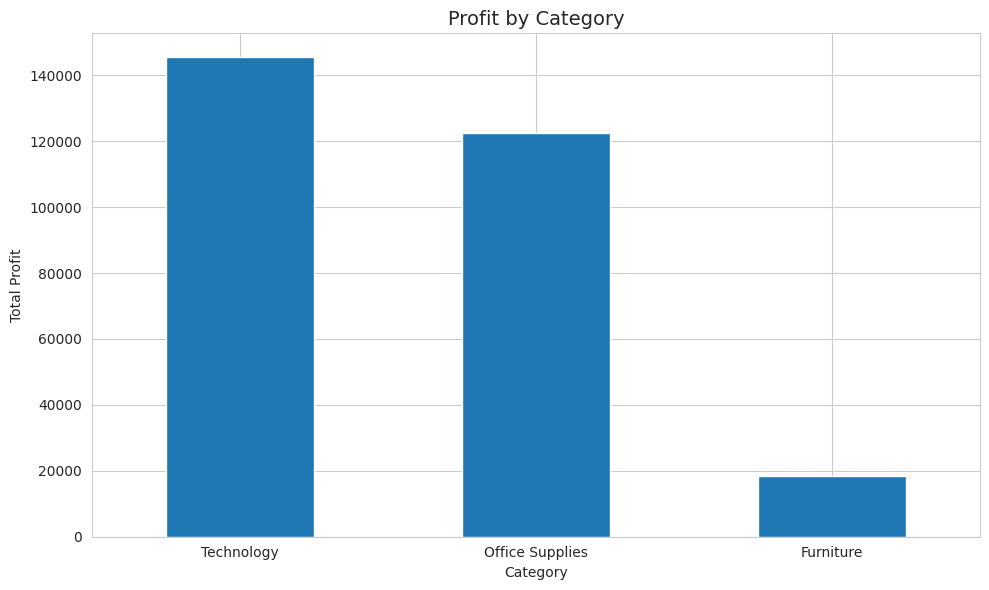

In [14]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
category_profit.plot(kind='bar')
plt.title("Profit by Category", fontsize=14)
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Insight

Technology leads in profit generation, indicating higher margins compared to other categories.

###6.4 Discount vs Profit Analysis

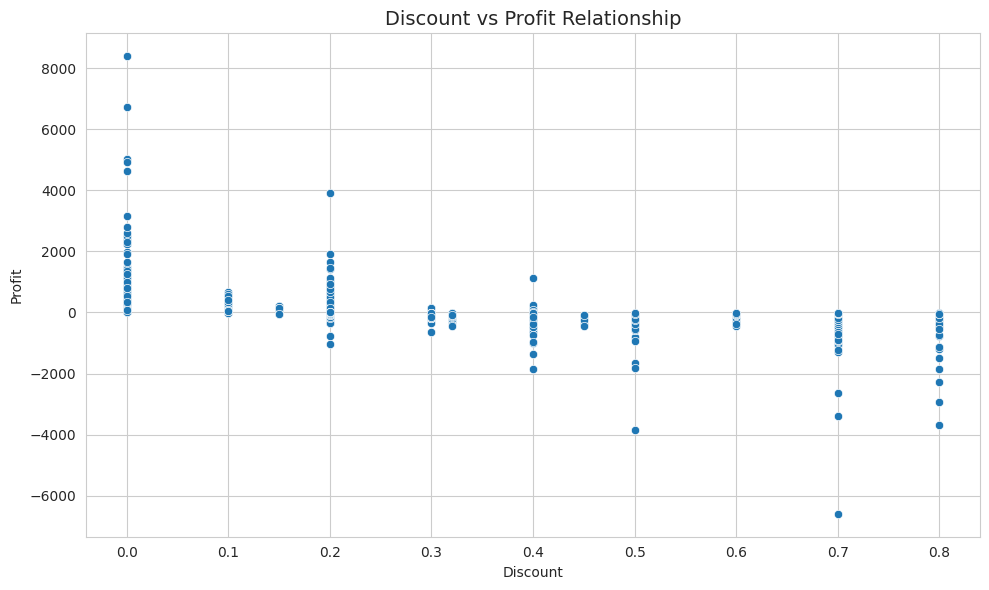

In [15]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['Discount'], y=df['Profit'])
plt.title("Discount vs Profit Relationship", fontsize=14)
plt.tight_layout()
plt.show()

### Insight

Higher discount levels correlate with reduced profitability. Aggressive discounting strategies may drive sales volume but negatively impact margins.

###6.5 Regional Sales Performance

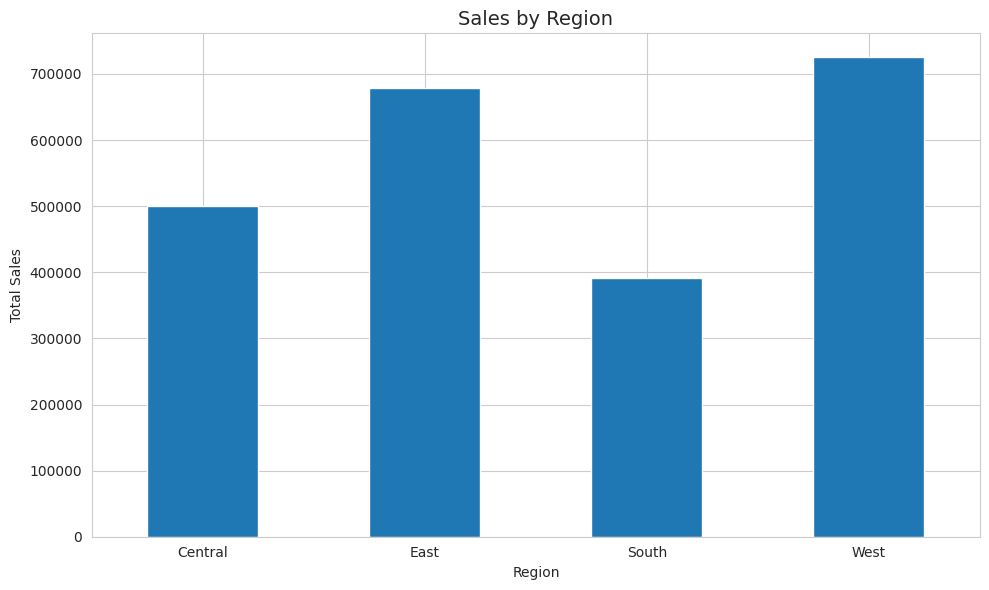

In [16]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(10,6))
region_sales.plot(kind='bar')
plt.title("Sales by Region", fontsize=14)
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Insight

Regional performance varies significantly, indicating opportunities for region-specific marketing and pricing strategies.

###📊 6.6 Correlation Analysis

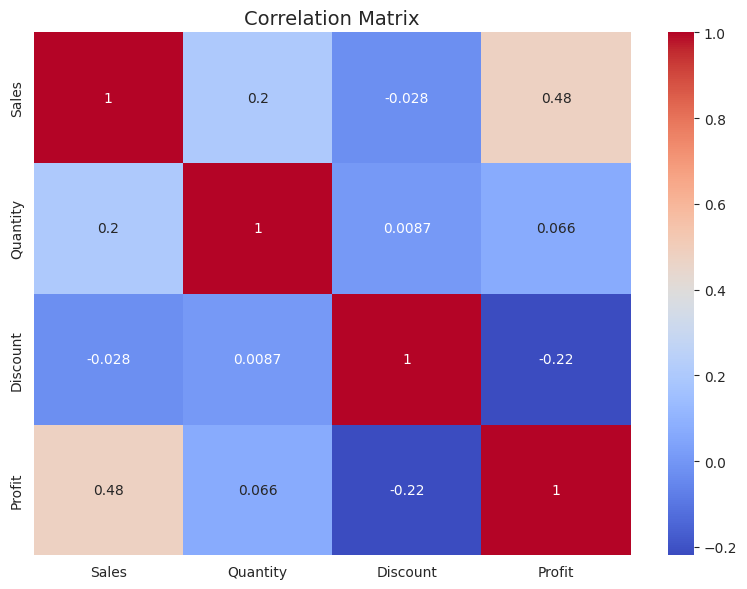

In [17]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Sales','Quantity','Discount','Profit']].corr(),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

### Insight

Profit is negatively influenced by discount levels, while sales and quantity show positive association.

## 5. Strategic Insights

1. Revenue growth remains strong, but margin control requires attention.
2. Technology category should be prioritized for expansion.
3. Discount optimization is critical to protect profitability.
4. Revenue concentration suggests focused inventory and marketing strategies.
5. Negative-margin transactions must be monitored and controlled.

## 6. Conclusion

This analysis demonstrates a structured data analytics workflow from cleaning to insight generation.

The findings emphasize the importance of balancing revenue growth with margin optimization.

Future enhancements may include:
• Customer segmentation analysis
• Predictive sales forecasting
• Profit optimization modeling
• Regional demand forecasting

This project reflects practical business analytics application using real-world retail data.